#   - Importation des bibliothèques et configuration

In [1]:

import cv2  
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import imagehash

from PIL import Image
from datasets import load_dataset

# Fixer le seed pour rendre les expériences scientifiques reproductibles
random.seed(42)
np.random.seed(42)

print("Bibliothèques chargées")

Bibliothèques chargées


# ACQUISITION - Chargement d'images d'objets 

In [2]:

print("Connexion à Hugging Face pour charger le dataset d'objets...")

# On utilise un dataset contenant des objets réels au lieu de documents textuels
dataset = load_dataset("Bingsu/Cat_and_Dog", split="train", streaming=True)

N_IMAGES_TOTAL = 100 # Échantillon statistique de 100 images
images_dataset = []

for i, example in enumerate(dataset):
    if i >= N_IMAGES_TOTAL:
        break
    
    # On convertit en RGB et on standardise la taille pour éviter la saturation de la RAM
    img = example['image'].convert('RGB').resize((500, 500))
    images_dataset.append(img)

print(f"Acquisition terminée : {len(images_dataset)} images d'objets prêtes pour le framework.")

Connexion à Hugging Face pour charger le dataset d'objets...
Acquisition terminée : 100 images d'objets prêtes pour le framework.


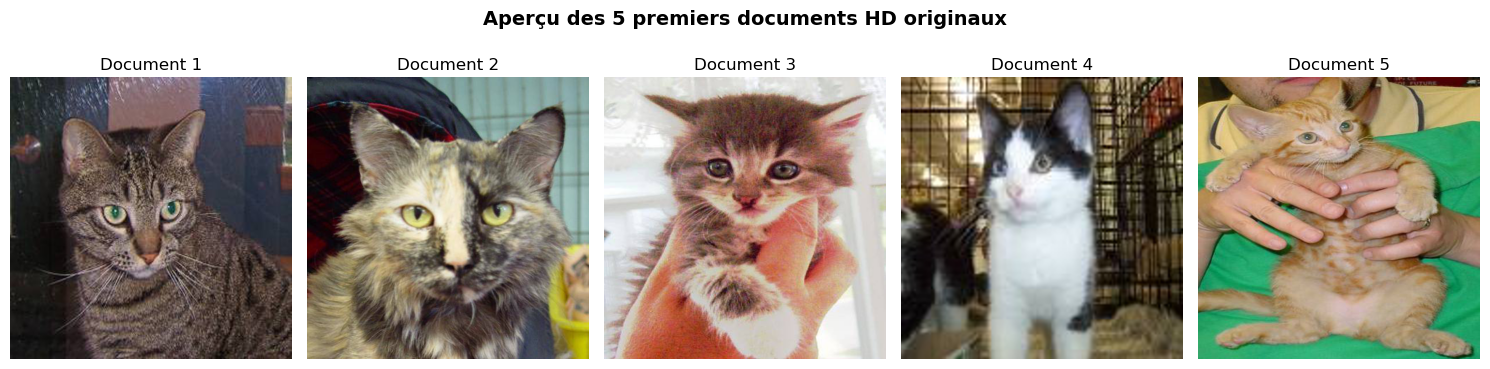

In [3]:
def afficher_echantillon(liste_images, nb_a_afficher=5, titre="Échantillon d'images"):
    """
    Affiche horizontalement un sous-ensemble d'images pour contrôle visuel.
    """
    nb = min(nb_a_afficher, len(liste_images))
    plt.figure(figsize=(15, 4))
    plt.suptitle(titre, fontsize=14, fontweight='bold')
    
    for i in range(nb):
        ax = plt.subplot(1, nb, i + 1)
        plt.imshow(liste_images[i])
        plt.title(f"Document {i+1}")
        plt.axis("off")
        
    plt.tight_layout()
    plt.show()

# Affichage les 5 premières images de notre dataset HD pour confirmer l'acquisition
afficher_echantillon(images_dataset, nb_a_afficher=5, titre="Aperçu des 5 premiers documents HD originaux")

# MODIFICATION - Opérations permises et altérations 


In [5]:
def pil_to_cv2(img_pil):
    """Convertit PIL (RGB) en matrice OpenCV (BGR)"""
    return cv2.cvtColor(np.array(img_pil), cv2.COLOR_RGB2BGR)

def cv2_to_pil(img_cv2):
    """Convertit matrice OpenCV (BGR) en PIL (RGB) pour le calcul de Hash"""
    return Image.fromarray(cv2.cvtColor(img_cv2, cv2.COLOR_BGR2RGB))

# ==========================================
# 1. OPÉRATIONS PERMISES (Modifications légitimes)
# ==========================================
def apply_compression_cv2(img, quality=30):
    img_cv2 = pil_to_cv2(img)
    encode_param = [int(cv2.IMWRITE_JPEG_QUALITY), quality]
    _, encimg = cv2.imencode('.jpg', img_cv2, encode_param)
    decimg = cv2.imdecode(encimg, 1)
    return cv2_to_pil(decimg)

def apply_resize_cv2(img, scale_percent=50):
    img_cv2 = pil_to_cv2(img)
    w = int(img_cv2.shape[1] * scale_percent / 100)
    h = int(img_cv2.shape[0] * scale_percent / 100)
    resized = cv2.resize(img_cv2, (w, h), interpolation=cv2.INTER_AREA)
    return cv2_to_pil(resized)

def add_gaussian_noise_cv2(img, sigma=8.0):
    img_cv2 = pil_to_cv2(img).astype(np.float32)
    noise = np.random.normal(0, sigma, img_cv2.shape).astype(np.float32)
    noisy = np.clip(img_cv2 + noise, 0, 255).astype(np.uint8)
    return cv2_to_pil(noisy)

def change_brightness_cv2(img, factor=1.2):
    img_cv2 = pil_to_cv2(img)
    # convertScaleAbs modifie le contraste (alpha) et la luminosité (beta)
    bright = cv2.convertScaleAbs(img_cv2, alpha=factor, beta=0)
    return cv2_to_pil(bright)

def blur_image_cv2(img, ksize=5): # ksize doit être impair dans cv2
    img_cv2 = pil_to_cv2(img)
    blurred = cv2.GaussianBlur(img_cv2, (ksize, ksize), 0)
    return cv2_to_pil(blurred)

def rotate_cv2(img, degrees=5.0):
    img_cv2 = pil_to_cv2(img)
    h, w = img_cv2.shape[:2]
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, degrees, 1.0)
    rotated = cv2.warpAffine(img_cv2, M, (w, h), flags=cv2.INTER_LINEAR)
    return cv2_to_pil(rotated)

# ==========================================
# 2. OPÉRATIONS NON PERMISES (Altérations)
# ==========================================
def apply_occlusion_cv2(img, area_percent=20):
    img_cv2 = pil_to_cv2(img)
    h, w = img_cv2.shape[:2]
    side = int(np.sqrt((w * h) * (area_percent / 100)))
    x0, y0 = (w - side) // 2, (h - side) // 2
    cv2.rectangle(img_cv2, (x0, y0), (x0 + side, y0 + side), (0, 0, 0), -1)
    return cv2_to_pil(img_cv2)

def big_shift_cv2(img, shift_percent=20):
    img_cv2 = pil_to_cv2(img)
    h, w = img_cv2.shape[:2]
    shift = int(w * (shift_percent / 100))
    M = np.float32([[1, 0, shift], [0, 1, 0]]) # Matrice de translation
    shifted = cv2.warpAffine(img_cv2, M, (w, h))
    return cv2_to_pil(shifted)

print("Toutes les fonctions OpenCV de modification sont chargées .")

Toutes les fonctions OpenCV de modification sont chargées .


# VISUALISATION_FILTRES - Test visuel des altérations OpenCV sur une image

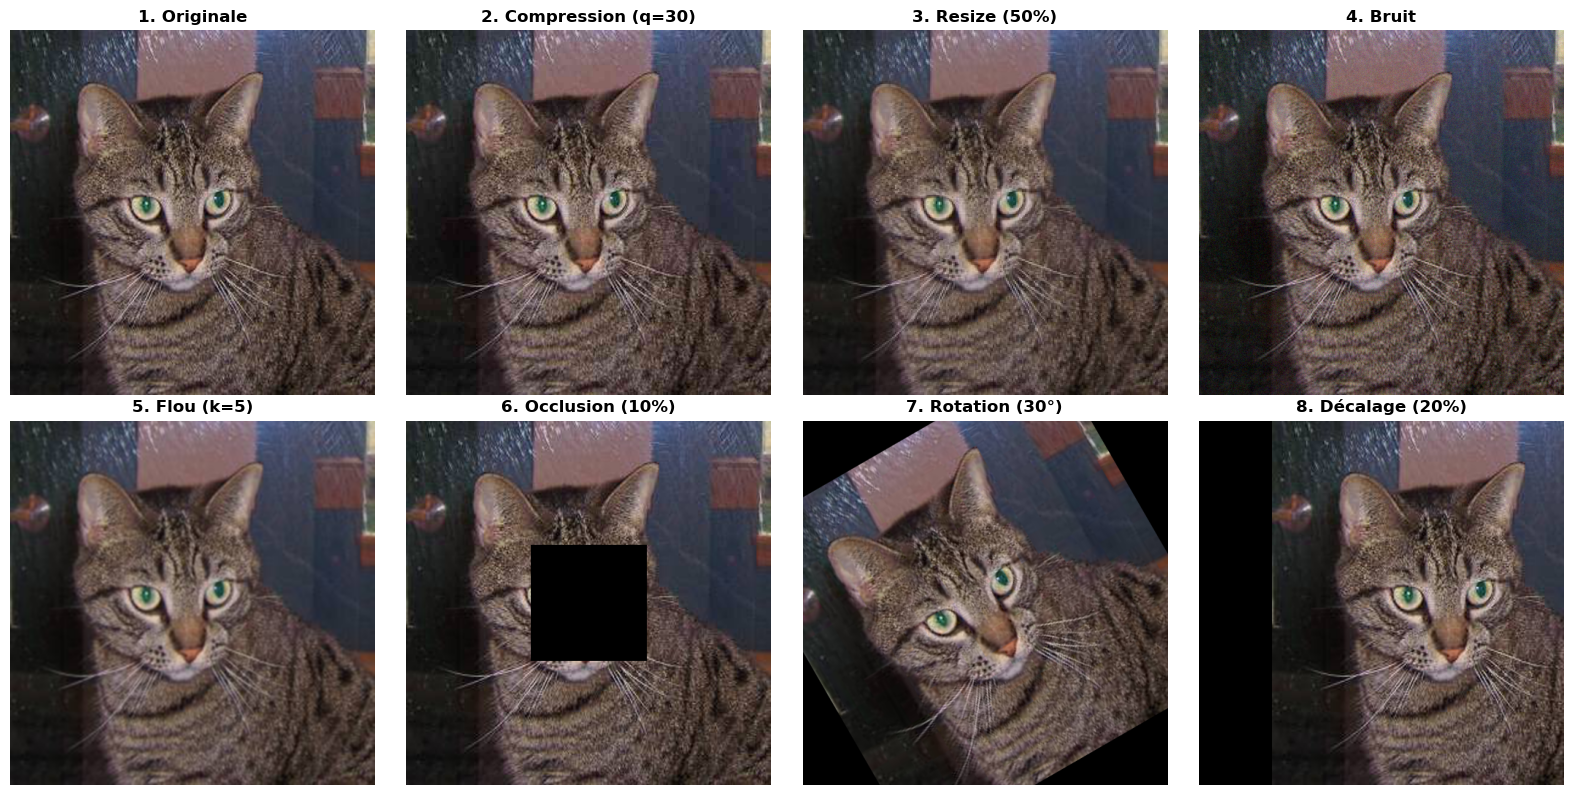

In [6]:

img_test = images_dataset[0]

# --- Opérations permises (OpenCV) ---
img_comp = apply_compression_cv2(img_test, quality=30)
img_res = apply_resize_cv2(img_test, scale_percent=50)
img_noise = add_gaussian_noise_cv2(img_test, sigma=8.0)
img_blur = blur_image_cv2(img_test, ksize=5) # ksize remplace radius pour OpenCV

# --- Opérations non permises (OpenCV) ---
img_occ = apply_occlusion_cv2(img_test, area_percent=10)
img_rot = rotate_cv2(img_test, degrees=30.0) # On réutilise rotate_cv2 avec un grand angle
img_shift = big_shift_cv2(img_test, shift_percent=20)

# Liste pour l'affichage (8 images au total)
images_testees = [
    img_test, img_comp, img_res, img_noise, 
    img_blur, img_occ, img_rot, img_shift
]

titres = [
    "1. Originale", "2. Compression (q=30)", "3. Resize (50%)", "4. Bruit",
    "5. Flou (k=5)", "6. Occlusion (10%)", "7. Rotation (30°)", "8. Décalage (20%)"
]

# Affichage sur 2 lignes et 4 colonnes
plt.figure(figsize=(16, 8))
for i in range(8):
    ax = plt.subplot(2, 4, i + 1)
    plt.imshow(images_testees[i])
    plt.title(titres[i], fontsize=12, fontweight='bold')
    plt.axis("off")
    
plt.tight_layout()
plt.show()

# EVALUATION_GRAPHIQUE - Évaluation OpenCV avec Pourcentages et Combinaisons


In [7]:
print("Début de l'évaluation sur les différents niveaux d'intensité et combinaisons...")

niveaux_compression = [90, 70, 50, 30, 10]
niveaux_resize = [90, 70, 50, 30, 10]
niveaux_occlusion = [1, 5, 10, 20, 30]

resultats_graphiques = []

# Fonction utilitaire pour calculer la distance ET le pourcentage (formule du prof)
def calculer_metriques(hash_orig, img_modifiee, fonction_hash):
    hash_mod = fonction_hash(img_modifiee)
    dist = hash_orig - hash_mod
    # Un hash perceptuel fait 64 bits. 0 de distance = 100% similaire.
    pourcentage = round((1 - (dist / 64.0)) * 100, 2)
    return dist, pourcentage

# On limite à 30 images pour garder un temps d'exécution rapide pour les graphiques
for idx, img_orig in enumerate(images_dataset[:30]):
    
    # Empreintes de référence (Images HD d'objets)
    hash_p_orig = imagehash.phash(img_orig)
    hash_a_orig = imagehash.average_hash(img_orig)
    hash_d_orig = imagehash.dhash(img_orig)
    hash_w_orig = imagehash.whash(img_orig) 
    
    # --- 1. COMPRESSION (Opération permise) ---
    for qualite in niveaux_compression:
        img_mod = apply_compression_cv2(img_orig, quality=qualite)
        
        dp, sp = calculer_metriques(hash_p_orig, img_mod, imagehash.phash)
        da, sa = calculer_metriques(hash_a_orig, img_mod, imagehash.average_hash)
        dd, sd = calculer_metriques(hash_d_orig, img_mod, imagehash.dhash)
        dw, sw = calculer_metriques(hash_w_orig, img_mod, imagehash.whash)

        resultats_graphiques.append({
            'Transformation': 'Compression', 'Intensite': qualite,
            'Dist_pHash': dp, 'Sim_pHash_%': sp,
            'Dist_aHash': da, 'Sim_aHash_%': sa,
            'Dist_dHash': dd, 'Sim_dHash_%': sd,
            'Dist_wHash': dw, 'Sim_wHash_%': sw
        })
        
    # --- 2. REDIMENSIONNEMENT (Opération permise) ---
    for scale in niveaux_resize:
        img_mod = apply_resize_cv2(img_orig, scale_percent=scale)
        
        dp, sp = calculer_metriques(hash_p_orig, img_mod, imagehash.phash)
        da, sa = calculer_metriques(hash_a_orig, img_mod, imagehash.average_hash)
        dd, sd = calculer_metriques(hash_d_orig, img_mod, imagehash.dhash)
        dw, sw = calculer_metriques(hash_w_orig, img_mod, imagehash.whash)

        resultats_graphiques.append({
            'Transformation': 'Resize', 'Intensite': scale,
            'Dist_pHash': dp, 'Sim_pHash_%': sp,
            'Dist_aHash': da, 'Sim_aHash_%': sa,
            'Dist_dHash': dd, 'Sim_dHash_%': sd,
            'Dist_wHash': dw, 'Sim_wHash_%': sw
        })
        
    # --- 3. OCCLUSION (Falsification) ---
    for area in niveaux_occlusion:
        img_mod = apply_occlusion_cv2(img_orig, area_percent=area)
        
        dp, sp = calculer_metriques(hash_p_orig, img_mod, imagehash.phash)
        da, sa = calculer_metriques(hash_a_orig, img_mod, imagehash.average_hash)
        dd, sd = calculer_metriques(hash_d_orig, img_mod, imagehash.dhash)
        dw, sw = calculer_metriques(hash_w_orig, img_mod, imagehash.whash)

        resultats_graphiques.append({
            'Transformation': 'Occlusion', 'Intensite': area,
            'Dist_pHash': dp, 'Sim_pHash_%': sp,
            'Dist_aHash': da, 'Sim_aHash_%': sa,
            'Dist_dHash': dd, 'Sim_dHash_%': sd,
            'Dist_wHash': dw, 'Sim_wHash_%': sw
        })
        
    # --- 4. ATTAQUE COMBINÉE ---
    # Scénario : L'attaquant compresse le fichier (50%) ET ajoute un faux élément (10%)
    img_mod = apply_occlusion_cv2(apply_compression_cv2(img_orig, quality=50), area_percent=10)
    
    dp, sp = calculer_metriques(hash_p_orig, img_mod, imagehash.phash)
    da, sa = calculer_metriques(hash_a_orig, img_mod, imagehash.average_hash)
    dd, sd = calculer_metriques(hash_d_orig, img_mod, imagehash.dhash)
    dw, sw = calculer_metriques(hash_w_orig, img_mod, imagehash.whash)

    resultats_graphiques.append({
        'Transformation': 'Combinee_Comp50_Occ10', 'Intensite': 100, # Intensité fictive pour le tableau
        'Dist_pHash': dp, 'Sim_pHash_%': sp,
        'Dist_aHash': da, 'Sim_aHash_%': sa,
        'Dist_dHash': dd, 'Sim_dHash_%': sd,
        'Dist_wHash': dw, 'Sim_wHash_%': sw
    })

df_graphiques = pd.DataFrame(resultats_graphiques)
print("Évaluation graphique terminée !")
display(df_graphiques.head())

Début de l'évaluation sur les différents niveaux d'intensité et combinaisons...
Évaluation graphique terminée !


,Transformation,Intensite,Dist_pHash,Sim_pHash_%,Dist_aHash,Sim_aHash_%,Dist_dHash,Sim_dHash_%,Dist_wHash,Sim_wHash_%
0,Compression,90,0,100.00,0,100.00,0,100.00,0,100.0
1,Compression,70,0,100.00,0,100.00,0,100.00,0,100.0
2,Compression,50,0,100.00,0,100.00,0,100.00,0,100.0
3,Compression,30,2,96.88,0,100.00,0,100.00,0,100.0
4,Compression,10,0,100.00,1,98.44,2,96.88,0,100.0


In [8]:
# [TAG: 04_VISUALISATION_RESULTATS] - Affichage des distances et pourcentages

print("1. Échantillon aléatoire des résultats globaux :")
display(df_graphiques.sample(10))

print("\n2. Zoom sur l'Occlusion (Falsification) - Observez la chute de similarité :")
# On trie par intensité pour bien voir l'évolution
df_occ = df_graphiques[df_graphiques['Transformation'] == 'Occlusion']
display(df_occ.sort_values(by='Intensite').head(10))

print("\n3. Zoom sur l'Attaque Combinée (Compression 50% + Occlusion 10%) :")
df_comb = df_graphiques[df_graphiques['Transformation'] == 'Combinee_Comp50_Occ10']
display(df_comb.head())

1. Échantillon aléatoire des résultats globaux :


,Transformation,Intensite,Dist_pHash,Sim_pHash_%,Dist_aHash,Sim_aHash_%,Dist_dHash,Sim_dHash_%,Dist_wHash,Sim_wHash_%
244,Compression,10,0,100.00,0,100.00,2,96.88,0,100.00
251,Occlusion,5,6,90.62,1,98.44,0,100.00,0,100.00
271,Combinee_Comp50_Occ10,100,8,87.50,8,87.50,5,92.19,4,93.75
459,Occlusion,5,6,90.62,1,98.44,2,96.88,2,96.88
290,Compression,50,2,96.88,0,100.00,0,100.00,0,100.00
414,Occlusion,30,12,81.25,23,64.06,22,65.62,28,56.25
115,Compression,30,0,100.00,0,100.00,0,100.00,0,100.00
106,Occlusion,1,2,96.88,0,100.00,0,100.00,2,96.88
323,Compression,30,0,100.00,0,100.00,0,100.00,0,100.00
174,Occlusion,30,22,65.62,7,89.06,11,82.81,6,90.62



2. Zoom sur l'Occlusion (Falsification) - Observez la chute de similarité :


,Transformation,Intensite,Dist_pHash,Sim_pHash_%,Dist_aHash,Sim_aHash_%,Dist_dHash,Sim_dHash_%,Dist_wHash,Sim_wHash_%
10,Occlusion,1,6,90.62,1,98.44,3,95.31,0,100.00
26,Occlusion,1,4,93.75,5,92.19,4,93.75,0,100.00
58,Occlusion,1,4,93.75,0,100.00,4,93.75,0,100.00
42,Occlusion,1,2,96.88,1,98.44,3,95.31,0,100.00
90,Occlusion,1,4,93.75,0,100.00,1,98.44,0,100.00
106,Occlusion,1,2,96.88,0,100.00,0,100.00,2,96.88
74,Occlusion,1,6,90.62,7,89.06,4,93.75,6,90.62
122,Occlusion,1,0,100.00,0,100.00,1,98.44,0,100.00
170,Occlusion,1,2,96.88,0,100.00,1,98.44,0,100.00
154,Occlusion,1,6,90.62,6,90.62,3,95.31,4,93.75



3. Zoom sur l'Attaque Combinée (Compression 50% + Occlusion 10%) :


,Transformation,Intensite,Dist_pHash,Sim_pHash_%,Dist_aHash,Sim_aHash_%,Dist_dHash,Sim_dHash_%,Dist_wHash,Sim_wHash_%
15,Combinee_Comp50_Occ10,100,12,81.25,13,79.69,9,85.94,12,81.25
31,Combinee_Comp50_Occ10,100,12,81.25,10,84.38,9,85.94,10,84.38
47,Combinee_Comp50_Occ10,100,4,93.75,3,95.31,5,92.19,2,96.88
63,Combinee_Comp50_Occ10,100,8,87.50,17,73.44,13,79.69,14,78.12
79,Combinee_Comp50_Occ10,100,6,90.62,23,64.06,10,84.38,20,68.75


# VISUALISATION_GRAPHIQUE - Boîtes à moustaches des distances


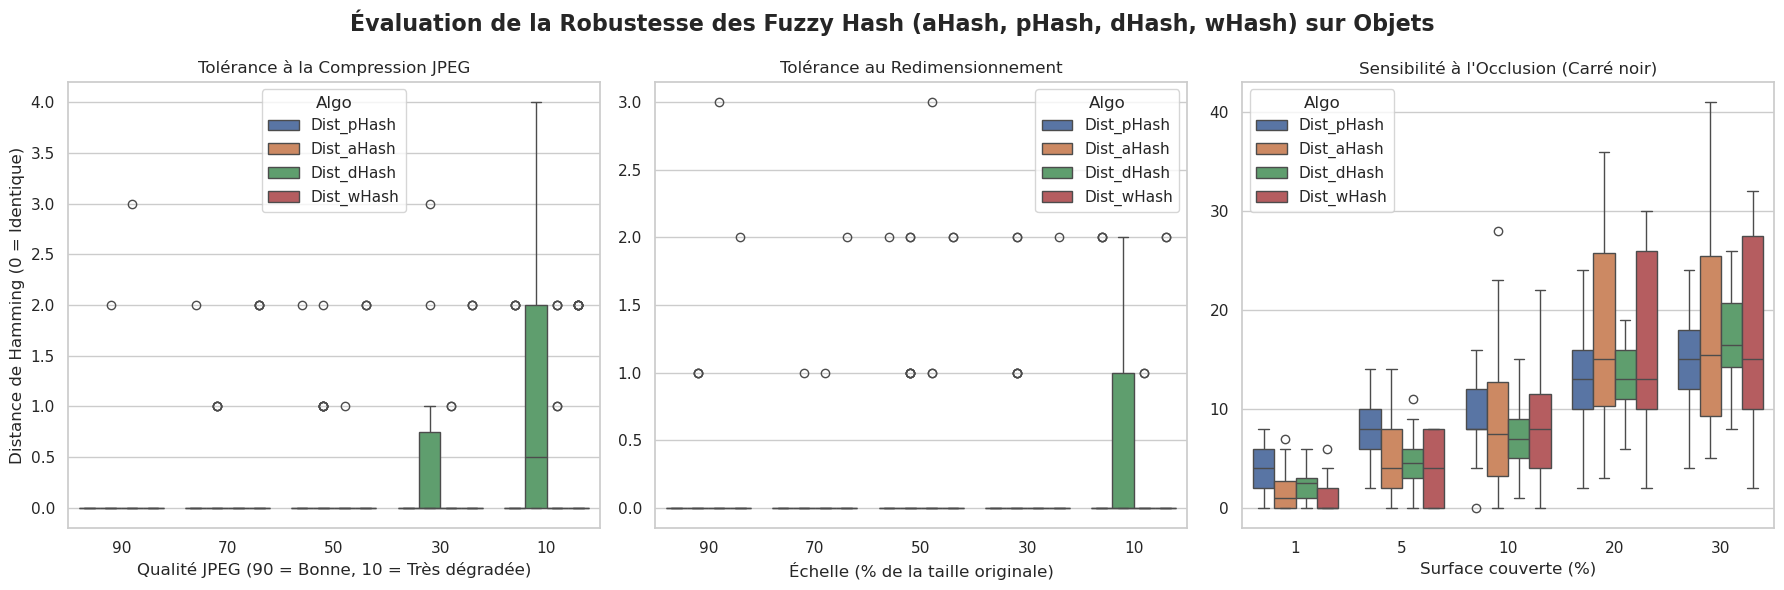

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# On configure le style visuel
sns.set_theme(style="whitegrid")

# On crée une figure avec 3 graphiques alignés
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Évaluation de la Robustesse des Fuzzy Hash (aHash, pHash, dHash, wHash) sur Objets", fontsize=16, fontweight='bold')

# NOUVELLES colonnes des distances à analyser
cols_distances = ['Dist_pHash', 'Dist_aHash', 'Dist_dHash', 'Dist_wHash']

# --- 1. Graphique Compression ---
df_comp = df_graphiques[df_graphiques['Transformation'] == 'Compression']
df_comp_melt = df_comp.melt(id_vars=['Intensite'], value_vars=cols_distances, var_name='Algo', value_name='Distance')

sns.boxplot(data=df_comp_melt, x='Intensite', y='Distance', hue='Algo', ax=axes[0])
axes[0].set_title('Tolérance à la Compression JPEG')
axes[0].set_xlabel('Qualité JPEG (90 = Bonne, 10 = Très dégradée)')
axes[0].set_ylabel('Distance de Hamming (0 = Identique)')
axes[0].invert_xaxis() # Pour que la qualité baisse de gauche à droite

# --- 2. Graphique Resize ---
df_res = df_graphiques[df_graphiques['Transformation'] == 'Resize']
df_res_melt = df_res.melt(id_vars=['Intensite'], value_vars=cols_distances, var_name='Algo', value_name='Distance')

sns.boxplot(data=df_res_melt, x='Intensite', y='Distance', hue='Algo', ax=axes[1])
axes[1].set_title('Tolérance au Redimensionnement')
axes[1].set_xlabel('Échelle (% de la taille originale)')
axes[1].set_ylabel('')
axes[1].invert_xaxis()

# --- 3. Graphique Occlusion ---
df_occ = df_graphiques[df_graphiques['Transformation'] == 'Occlusion']
df_occ_melt = df_occ.melt(id_vars=['Intensite'], value_vars=cols_distances, var_name='Algo', value_name='Distance')

sns.boxplot(data=df_occ_melt, x='Intensite', y='Distance', hue='Algo', ax=axes[2])
axes[2].set_title('Sensibilité à l\'Occlusion (Carré noir)')
axes[2].set_xlabel('Surface couverte (%)')
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()

# EVALUATION_STATISTIQUE - Évaluation statistique exhaustive

In [12]:
import gc
import numpy as np

print("Calcul exhaustif des distances pour le seuil (FPR <= 1%)...")

HASHERS = {
    "aHash": lambda im: imagehash.average_hash(im),
    "pHash": lambda im: imagehash.phash(im),
    "dHash": lambda im: imagehash.dhash(im),
    "wHash": lambda im: imagehash.whash(im),
}

pos_dists = {name: [] for name in HASHERS}
neg_dists = {name: [] for name in HASHERS}

# Listes déterministes d'opérations (OpenCV)
operations_permises = [
    lambda img: apply_compression_cv2(img, quality=50),
    lambda img: apply_compression_cv2(img, quality=10),
    lambda img: apply_resize_cv2(img, scale_percent=50),
    lambda img: blur_image_cv2(img, ksize=5),
]

falsifications = [
    lambda img: apply_occlusion_cv2(img, area_percent=10),
    lambda img: apply_occlusion_cv2(img, area_percent=30),
    lambda img: apply_occlusion_cv2(apply_compression_cv2(img, 50), 20) # Combinée
]

# --- 1. PAIRES POSITIVES (Modifications légitimes) ---
for img in images_dataset:
    for op in operations_permises:
        img_mod = op(img)
        for name, hasher in HASHERS.items():
            pos_dists[name].append(hasher(img) - hasher(img_mod))
        del img_mod
gc.collect()

# --- 2. PAIRES NÉGATIVES (Falsifications et documents différents) ---
N_IMAGES = len(images_dataset)

for i, img1 in enumerate(images_dataset):
    # a) Falsifications sur l'image elle-même
    for op in falsifications:
        img_mod = op(img1)
        for name, hasher in HASHERS.items():
            neg_dists[name].append(hasher(img1) - hasher(img_mod))
        del img_mod
        
    # b) Comparaison avec une image totalement différente
    # On compare systématiquement avec l'image suivante pour être déterministe
    img2 = images_dataset[(i + 1) % N_IMAGES]
    for name, hasher in HASHERS.items():
        neg_dists[name].append(hasher(img1) - hasher(img2))

gc.collect()

# --- 3. CALCUL DU SEUIL ---
def choose_threshold_by_fpr(pos_d, neg_d, target_fpr=0.01):
    neg_sorted = np.sort(neg_d)
    idx = int(np.floor(target_fpr * len(neg_sorted)))
    idx = max(0, min(idx, len(neg_sorted)-1))
    return int(neg_sorted[idx])

def evaluate_at_tau(pos_d, neg_d, tau):
    tp = int(np.sum(pos_d <= tau)) #Vrais Positifs (Légitimes acceptés)
    fn = int(np.sum(pos_d > tau)) #Faux Négatifs (Légitimes bloqués à tort)
    fp = int(np.sum(neg_d <= tau)) #Faux Positifs (Fraudes acceptées à tort)
    tn = int(np.sum(neg_d > tau)) #Vrais Négatifs (Fraudes bloquées)

    recall = tp / (tp + fn + 1e-9)
    fpr = fp / (fp + tn + 1e-9)
    precision = tp / (tp + fp + 1e-9)
    f1 = 2 * precision * recall / (precision + recall + 1e-9)
    return {"tau": tau, "F1-Score": round(f1, 4), "Recall": round(recall, 4)}

print("\nRésultats de l'évaluation (Déterministe OpenCV) :")
for name in HASHERS:
    p_d = np.array(pos_dists[name])
    n_d = np.array(neg_dists[name])
    
    tau = choose_threshold_by_fpr(p_d, n_d, target_fpr=0.01)
    metrics = evaluate_at_tau(p_d, n_d, tau)
    sim_tau_pct = round((1 - (tau / 64.0)) * 100, 2) # Formule appliquee
    
    print(f"\n=== {name} ===")
    print(f"Dist. Moyenne (Permis) : {float(p_d.mean()):.2f} | (Falsifié) : {float(n_d.mean()):.2f}")
    print(f"--> Seuil mathématique (τ) : {tau} (soit {sim_tau_pct}% de similarité min.)")
    print(f"--> F1-Score: {metrics['F1-Score']} | Recall: {metrics['Recall']}")

Calcul exhaustif des distances pour le seuil (FPR <= 1%)...

Résultats de l'évaluation (Déterministe OpenCV) :

=== aHash ===
Dist. Moyenne (Permis) : 0.08 | (Falsifié) : 19.51
--> Seuil mathématique (τ) : 2 (soit 96.88% de similarité min.)
--> F1-Score: 0.9901 | Recall: 0.9975

=== pHash ===
Dist. Moyenne (Permis) : 0.20 | (Falsifié) : 17.32
--> Seuil mathématique (τ) : 2 (soit 96.88% de similarité min.)
--> F1-Score: 0.9913 | Recall: 0.995

=== dHash ===
Dist. Moyenne (Permis) : 0.39 | (Falsifié) : 17.14
--> Seuil mathématique (τ) : 3 (soit 95.31% de similarité min.)
--> F1-Score: 0.9851 | Recall: 0.9925

=== wHash ===
Dist. Moyenne (Permis) : 0.09 | (Falsifié) : 18.85
--> Seuil mathématique (τ) : 0 (soit 100.0% de similarité min.)
--> F1-Score: 0.9695 | Recall: 0.955


In [13]:
import pandas as pd
import datetime

resultats_finaux = []

for name in HASHERS:
    p_d = np.array(pos_dists[name])
    n_d = np.array(neg_dists[name])
    
    tau = choose_threshold_by_fpr(p_d, n_d, target_fpr=0.01)
    metrics = evaluate_at_tau(p_d, n_d, tau)
    sim_tau_pct = round((1 - (tau / 64.0)) * 100, 2)
    
    resultats_finaux.append({
        "Algorithme": name,
        "Dist_Moyenne_Permis": round(float(p_d.mean()), 2),
        "Dist_Moyenne_Falsifie": round(float(n_d.mean()), 2),
        "Seuil_Optimal_Tau": tau,
        "Similarite_Minimale_%": sim_tau_pct,
        "F1_Score": metrics['F1-Score'],
        "Recall": metrics['Recall']
    })

df_finaux = pd.DataFrame(resultats_finaux)

date_jour = datetime.datetime.now().strftime("%Y-%m-%d")
nom_fichier = f"seuils_optimaux_opencv_{date_jour}.csv"

df_finaux.to_csv(nom_fichier, index=False)

print(f"Fichier généré : {nom_fichier}")
#display(df_finaux)

Fichier généré : seuils_optimaux_opencv_2026-02-26.csv
